# Phase 2: Matrix Factorization from Scratch

## 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_parquet('../data/processed/ratings.parquet')
ratings.head()

,userId,movieId,rating,rated_at
0,1,296,5.0,2006-05-17 15:34:04+00:00
1,1,306,3.5,2006-05-17 12:26:57+00:00
2,1,307,5.0,2006-05-17 12:27:08+00:00
3,1,665,5.0,2006-05-17 15:13:40+00:00
4,1,899,3.5,2006-05-17 12:21:50+00:00


## 2. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
ratings_small = ratings.sample(frac=0.02, random_state=42)  # 2%만
train, test = train_test_split(ratings_small, test_size=0.2, random_state=42)
train_array = train[['userId', 'movieId', 'rating']].values
test_array = test[['userId', 'movieId', 'rating']].values

print(f"train: {train_array.shape}, test: {test_array.shape}")

train: (400001, 3), test: (100001, 3)


## 3. Model

In [6]:
import sys
sys.path.append('../')

from src.mf_model import MatrixFactorization

model = MatrixFactorization(n_factors=20, lr=0.005, lambda_=0.05, n_epochs=100, patience=5)
model.fit(train_array, val_ratings=test_array)

Epoch   1/100 | Train RMSE: 1.0161 | Val RMSE: 0.9888
Epoch   2/100 | Train RMSE: 0.9767 | Val RMSE: 0.9688
Epoch   3/100 | Train RMSE: 0.9559 | Val RMSE: 0.9567
Epoch   4/100 | Train RMSE: 0.9407 | Val RMSE: 0.9479
Epoch   5/100 | Train RMSE: 0.9285 | Val RMSE: 0.9414
Epoch   6/100 | Train RMSE: 0.9183 | Val RMSE: 0.9361
Epoch   7/100 | Train RMSE: 0.9094 | Val RMSE: 0.9318
Epoch   8/100 | Train RMSE: 0.9016 | Val RMSE: 0.9282
Epoch   9/100 | Train RMSE: 0.8945 | Val RMSE: 0.9252
Epoch  10/100 | Train RMSE: 0.8881 | Val RMSE: 0.9226
Epoch  11/100 | Train RMSE: 0.8822 | Val RMSE: 0.9203
Epoch  12/100 | Train RMSE: 0.8768 | Val RMSE: 0.9185
Epoch  13/100 | Train RMSE: 0.8717 | Val RMSE: 0.9168
Epoch  14/100 | Train RMSE: 0.8670 | Val RMSE: 0.9153
Epoch  15/100 | Train RMSE: 0.8625 | Val RMSE: 0.9140
Epoch  16/100 | Train RMSE: 0.8583 | Val RMSE: 0.9128
Epoch  17/100 | Train RMSE: 0.8543 | Val RMSE: 0.9121
Epoch  18/100 | Train RMSE: 0.8506 | Val RMSE: 0.9110
Epoch  19/100 | Train RMSE: 

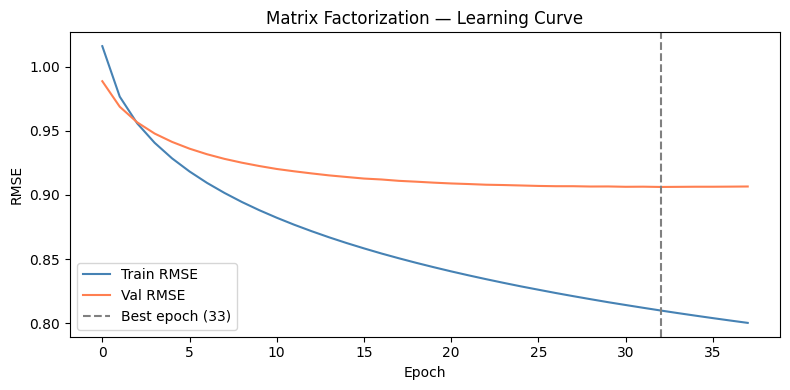

In [7]:
import os
os.makedirs('../images', exist_ok=True)
model.plot_loss()

## 4. Training Results

Early stopping stopped training at epoch 38, with the best model saved at **epoch 33** (val RMSE: **0.9062**).

The gap between train and val RMSE is ~0.10, indicating minimal overfitting — a significant improvement over the initial model (gap was 0.65 without bias terms).

Key design decisions:
- **Bias terms** (μ + b_u + b_i): captures user/item rating tendencies independent of latent factors
- **Early stopping** (patience=5): prevents overfitting without manual epoch tuning
- **L2 regularization** (λ=0.05): penalizes large latent factor values

## 5. Evaluation

RMSE measures average prediction error on held-out ratings.
A val RMSE of ~0.90 on a 0.5–5.0 scale means predictions are off by less than 1 star on average.

For context, the Netflix Prize winning solution achieved ~0.856 RMSE on a similar task.

## 6. Key Observations

1. **Bias terms matter more than latent factors**: Adding μ + b_u + b_i dropped val RMSE from 1.19 → 0.91. This makes sense — much of rating variance is explained by "this user rates high" or "this item is rated low" patterns.

2. **Overfitting is under control**: Train/val gap of ~0.10 is acceptable. Earlier runs without bias terms showed a gap of 0.65.

3. **Limitation — RMSE alone is not enough**: RMSE measures prediction accuracy, not recommendation quality. A model can achieve low RMSE while still over-recommending popular items. This is exactly the popularity bias problem identified in Phase 1.

4. **Next**: `04_evaluation_metrics.ipynb` evaluates ranking quality (NDCG@K), catalog coverage, and long-tail exposure — metrics that directly connect back to the Phase 1 findings.